# Monte Carlo Prediction no Blackjack

Notebook independente para o experimento com **Monte Carlo Prediction — First Visit** no `Blackjack-v1`, tomando como base a implementação disponibilizada na disciplina.

Nesta etapa, a política é fixa:

- `hit` quando a soma do jogador é menor que 20;
- `stick` quando a soma é 20 ou 21.

O objetivo é analisar como o número de episódios afeta a estabilidade da estimativa de \(V^\pi(s)\).


## 1. Introdução

O agente não aprende uma política nesta etapa. Ele executa repetidamente uma política fixa e utiliza retornos completos de episódios para estimar a função de valor.

### Hipótese

Espera-se que:

- 10.000 episódios produzam maior variabilidade entre execuções;
- 100.000 episódios produzam estimativas mais estáveis;
- 500.000 episódios aproximem ainda mais as diferentes repetições.


## 2. Fundamentação teórica

### 2.1 Monte Carlo Prediction — First Visit

O retorno a partir do instante \(t\) é:

$$
G_t =
R_{t+1}
+ \gamma R_{t+2}
+ \gamma^2 R_{t+3}
+ \cdots
$$

No método **First Visit**, apenas a primeira ocorrência de um estado em cada episódio é usada na atualização.

$$
V(s_t)
\leftarrow
V(s_t)
+
\frac{1}{N(s_t)}
\left(
G_t - V(s_t)
\right)
$$

onde \(N(s_t)\) é o número de primeiras visitas ao estado.


### 2.2 Ambiente Blackjack-v1

O estado é:

$$
(\text{soma do jogador},\ \text{carta visível do dealer},\ \text{ás utilizável})
$$

Ações:

- `0 = stick`
- `1 = hit`

Recompensas terminais:

- vitória: `+1`
- empate: `0`
- derrota: `-1`

Configuração:

- `natural=False`
- `sab=False`


## 3. Configuração experimental


In [1]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

from collections import defaultdict

%matplotlib inline
matplotlib.style.use("ggplot")


### 3.1 Parâmetros

São testadas três quantidades de episódios:

- 10.000
- 100.000
- 500.000

Cada configuração é repetida com cinco seeds independentes. A mesma lista de seeds é utilizada em todas as configurações.


In [2]:
BASE_SEED = 42
N_RUNS = 5
SEEDS = [BASE_SEED + i for i in range(N_RUNS)]

GAMMA = 1.0

PREDICTION_EPISODES = [
    10_000,
    100_000,
    500_000,
]

print("Seeds:", SEEDS)
print("Episódios:", PREDICTION_EPISODES)


Seeds: [42, 43, 44, 45, 46]
Episódios: [10000, 100000, 500000]


### 3.2 Ambiente e controle da seed

A seed é aplicada **uma vez no início de cada repetição experimental**.

Depois disso, chamadas subsequentes a `reset()` continuam consumindo a sequência pseudoaleatória do mesmo gerador. Assim, os episódios são diferentes entre si, mas a repetição completa permanece reproduzível.


In [3]:
def make_env():
    return gym.make(
        "Blackjack-v1",
        natural=False,
        sab=False
    )


## 4. Política fixa


In [4]:
def sample_policy(observation):
    player_sum, dealer_card, usable_ace = observation
    return 0 if player_sum >= 20 else 1


## 5. Geração de episódios

A função recebe explicitamente o ambiente para preservar o controle sobre o gerador pseudoaleatório durante toda a repetição.


In [5]:
def generate_episode(env, policy):
    episode = []
    observation, info = env.reset()

    while True:
        action = policy(observation)

        next_observation, reward, terminated, truncated, info = env.step(action)

        episode.append((observation, action, reward))
        observation = next_observation

        if terminated or truncated:
            break

    return episode


## 6. Monte Carlo Prediction — First Visit

Para cada episódio:

1. gera-se a trajetória completa;
2. percorrem-se os estados na ordem em que aparecem;
3. apenas a primeira ocorrência de cada estado é utilizada;
4. calcula-se \(G_t\);
5. atualiza-se a média dos retornos daquele estado.


In [6]:
def mc_prediction(policy, env, num_episodes, gamma=1.0):
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)
    V = defaultdict(float)

    for _ in range(num_episodes):
        episode = generate_episode(env, policy)
        visited_states = set()

        for t, (state, action, reward) in enumerate(episode):
            state = tuple(state)

            if state in visited_states:
                continue

            visited_states.add(state)

            G = 0.0
            for k, (_, _, reward_k) in enumerate(episode[t:]):
                G += (gamma ** k) * reward_k

            returns_sum[state] += G
            returns_count[state] += 1
            V[state] = returns_sum[state] / returns_count[state]

    return V, returns_count


## 7. Execução das repetições


In [7]:
prediction_results = {}

for num_episodes in PREDICTION_EPISODES:
    prediction_results[num_episodes] = []

    for seed in SEEDS:
        env = make_env()

        # Inicializa o RNG desta repetição.
        env.reset(seed=seed)

        V, visit_counts = mc_prediction(
            sample_policy,
            env,
            num_episodes=num_episodes,
            gamma=GAMMA
        )

        prediction_results[num_episodes].append({
            "seed": seed,
            "V": V,
            "visit_counts": visit_counts
        })

        env.close()

    print(
        f"{num_episodes:,} episódios: "
        f"{len(prediction_results[num_episodes])} repetições concluídas"
    )


10,000 episódios: 5 repetições concluídas
100,000 episódios: 5 repetições concluídas
500,000 episódios: 5 repetições concluídas


## 8. Visualização da função de valor

A função de valor é mostrada separando estados:

- sem ás utilizável;
- com ás utilizável.

O eixo X representa a soma do jogador, o eixo Y a carta visível do dealer e a cor representa $$V^\pi(s)$$.


In [8]:
PLAYER_SUMS = np.arange(12, 22)
DEALER_CARDS = np.arange(1, 11)

def value_matrix(V, usable_ace):
    matrix = np.full(
        (len(DEALER_CARDS), len(PLAYER_SUMS)),
        np.nan
    )

    for i, dealer in enumerate(DEALER_CARDS):
        for j, player_sum in enumerate(PLAYER_SUMS):
            state = (int(player_sum), int(dealer), bool(usable_ace))

            if state in V:
                matrix[i, j] = V[state]

    return matrix

def plot_value_heatmaps(V, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, usable_ace, subtitle in [
        (axes[0], False, "Sem ás utilizável"),
        (axes[1], True, "Com ás utilizável"),
    ]:
        matrix = value_matrix(V, usable_ace)

        image = ax.imshow(
            matrix,
            origin="lower",
            aspect="auto",
            vmin=-1,
            vmax=1,
            cmap="coolwarm"
        )

        ax.set_xticks(np.arange(len(PLAYER_SUMS)))
        ax.set_xticklabels(PLAYER_SUMS)
        ax.set_yticks(np.arange(len(DEALER_CARDS)))
        ax.set_yticklabels(DEALER_CARDS)

        ax.set_xlabel("Soma do jogador")
        ax.set_ylabel("Carta visível do dealer")
        ax.set_title(subtitle)

    fig.suptitle(title)
    fig.colorbar(
        image,
        ax=axes.ravel().tolist(),
        label="V(s)"
    )

    plt.show()


### 8.1 Uma repetição por configuração

Para comparação visual, usa-se a repetição com `seed=42` em cada quantidade de episódios.


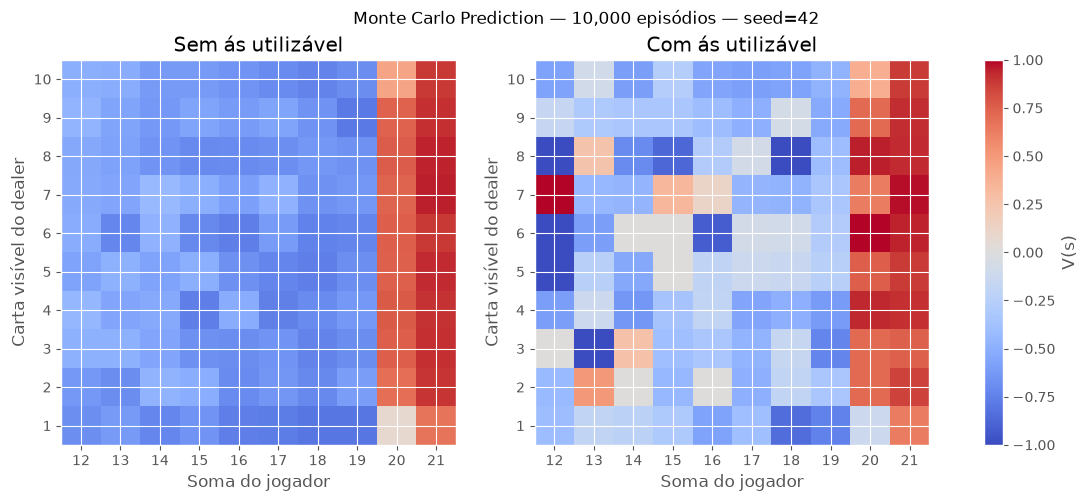

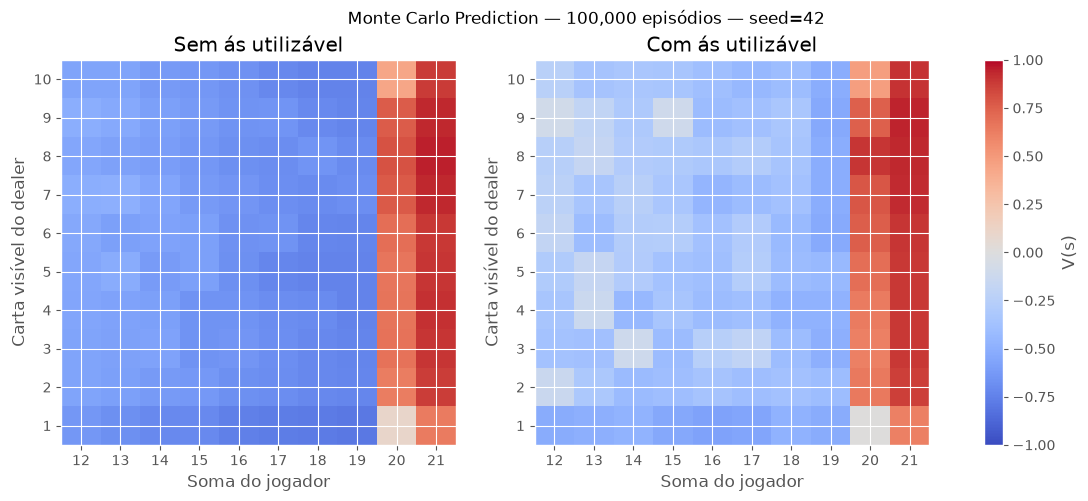

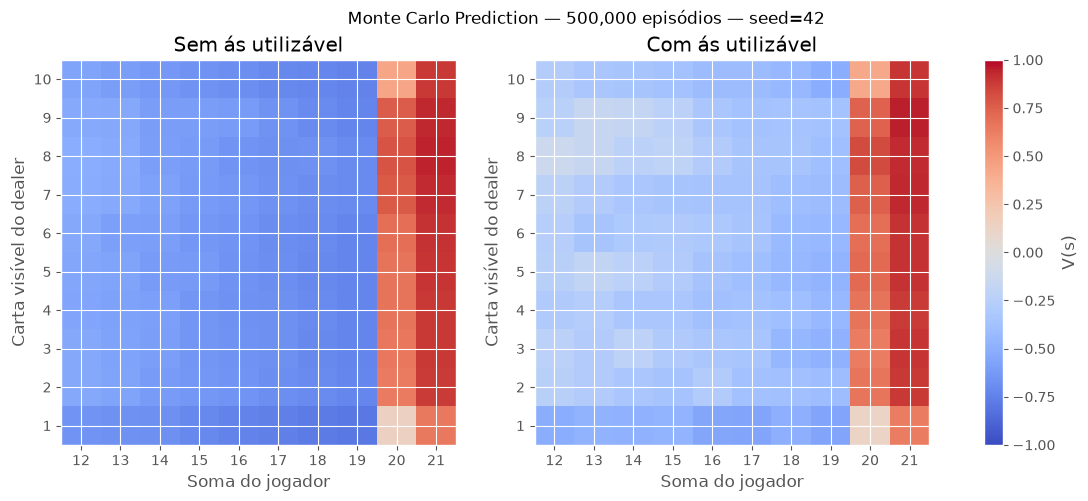

In [9]:
for num_episodes in PREDICTION_EPISODES:
    result = prediction_results[num_episodes][0]

    plot_value_heatmaps(
        result["V"],
        title=(
            f"Monte Carlo Prediction — "
            f"{num_episodes:,} episódios — "
            f"seed={result['seed']}"
        )
    )


## 9. Estabilidade entre repetições

Para cada estado, calcula-se o desvio padrão de \(V(s)\) entre as cinco seeds.

Depois é calculada a média desses desvios padrão.

Quanto menor essa métrica, maior a estabilidade da estimativa entre diferentes repetições.


In [10]:
def collect_state_values(runs):
    all_states = set()

    for run in runs:
        all_states.update(run["V"].keys())

    rows = []

    for state in sorted(all_states):
        values = [
            run["V"].get(state, np.nan)
            for run in runs
        ]

        rows.append({
            "state": state,
            "values": values
        })

    return rows

stability_rows = []

for num_episodes, runs in prediction_results.items():
    state_rows = collect_state_values(runs)
    state_stds = []

    for row in state_rows:
        values = np.asarray(row["values"], dtype=float)
        state_stds.append(np.nanstd(values))

    stability_rows.append({
        "Episódios": num_episodes,
        "Desvio padrão médio de V": np.mean(state_stds),
        "Estados observados": len(state_rows),
    })

stability_df = pd.DataFrame(stability_rows)
stability_df


,Episódios,Desvio padrão médio de V,Estados observados
0,10000,0.148139,280
1,100000,0.043175,280
2,500000,0.019333,280


### 9.1 Gráfico de estabilidade


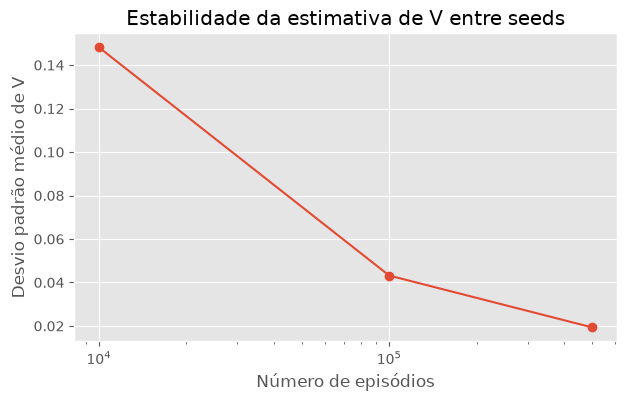

In [11]:
plt.figure(figsize=(7, 4))

plt.plot(
    stability_df["Episódios"],
    stability_df["Desvio padrão médio de V"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Número de episódios")
plt.ylabel("Desvio padrão médio de V")
plt.title("Estabilidade da estimativa de V entre seeds")
plt.grid(True)

plt.show()


## 10. Estados representativos

Além da métrica agregada, alguns estados específicos são acompanhados para observar média e variabilidade de \(V(s)\).


In [12]:
REPRESENTATIVE_STATES = [
    (13, 2, False),
    (18, 10, False),
    (20, 10, False),
    (18, 6, True),
    (20, 6, True),
]

state_comparison_rows = []

for num_episodes, runs in prediction_results.items():
    for state in REPRESENTATIVE_STATES:
        values = np.asarray([
            run["V"].get(state, np.nan)
            for run in runs
        ])

        state_comparison_rows.append({
            "Episódios": num_episodes,
            "Estado": str(state),
            "V médio": np.nanmean(values),
            "Desvio padrão": np.nanstd(values),
        })

state_comparison_df = pd.DataFrame(state_comparison_rows)
state_comparison_df


,Episódios,Estado,V médio,Desvio padrão
0,10000,"(13, 2, False)",-0.615167,0.066685
1,10000,"(18, 10, False)",-0.723527,0.033477
2,10000,"(20, 10, False)",0.427551,0.034345
3,10000,"(18, 6, True)",-0.473096,0.337101
4,10000,"(20, 6, True)",0.672136,0.275441
5,100000,"(13, 2, False)",-0.563884,0.015357
6,100000,"(18, 10, False)",-0.727084,0.008367
7,100000,"(20, 10, False)",0.435833,0.009968
8,100000,"(18, 6, True)",-0.391606,0.045087
9,100000,"(20, 6, True)",0.706588,0.040999


### 10.1 Frequência de visitas aos estados representativos

A estabilidade da estimativa de \(V(s)\) depende da quantidade de vezes que cada estado é efetivamente visitado.

Nesta seção são comparadas as primeiras visitas aos mesmos estados representativos utilizados anteriormente.

In [17]:
visit_comparison_rows = []

for num_episodes, runs in prediction_results.items():

    for state in REPRESENTATIVE_STATES:

        counts = np.asarray([
            run["visit_counts"].get(state, 0)
            for run in runs
        ])

        visit_comparison_rows.append({
            "Episódios": num_episodes,
            "Estado": str(state),
            "Visitas médias": np.mean(counts),
            "Desvio padrão das visitas": np.std(counts),
        })

visit_comparison_df = pd.DataFrame(
    visit_comparison_rows
)

visit_comparison_df["CV das visitas"] = (
    visit_comparison_df["Desvio padrão das visitas"]
    / visit_comparison_df["Visitas médias"]
)

visit_comparison_df["Frequência média"] = (
    visit_comparison_df["Visitas médias"]
    / visit_comparison_df["Episódios"]
)

visit_comparison_df

,Episódios,Estado,Visitas médias,Desvio padrão das visitas,CV das visitas,Frequência média
0,10000,"(13, 2, False)",89.0,10.373042,0.116551,0.008900
1,10000,"(18, 10, False)",446.6,21.574058,0.048307,0.044660
2,10000,"(20, 10, False)",610.8,20.595145,0.033718,0.061080
3,10000,"(18, 6, True)",13.8,2.785678,0.201861,0.001380
4,10000,"(20, 6, True)",16.0,3.898718,0.243670,0.001600
5,100000,"(13, 2, False)",953.6,23.888072,0.025050,0.009536
6,100000,"(18, 10, False)",4349.8,38.238201,0.008791,0.043498
7,100000,"(20, 10, False)",6088.0,57.445626,0.009436,0.060880
8,100000,"(18, 6, True)",153.4,8.957678,0.058394,0.001534
9,100000,"(20, 6, True)",179.2,6.645299,0.037083,0.001792


### 10.2 Visualização da frequência de visitas

Os gráficos abaixo mostram o número médio de primeiras visitas aos estados representativos em cada configuração experimental.

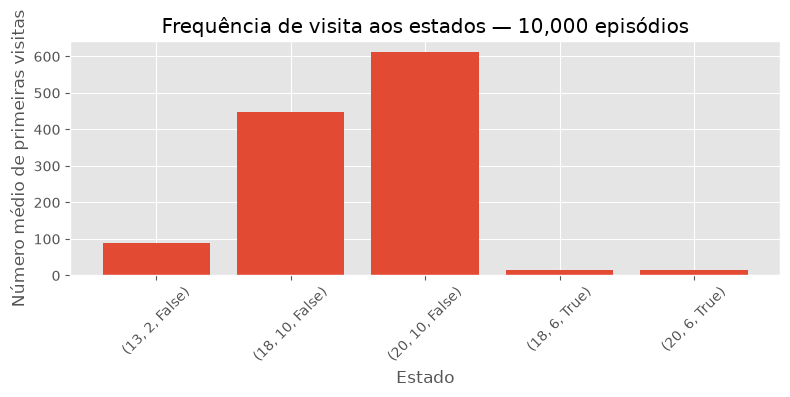

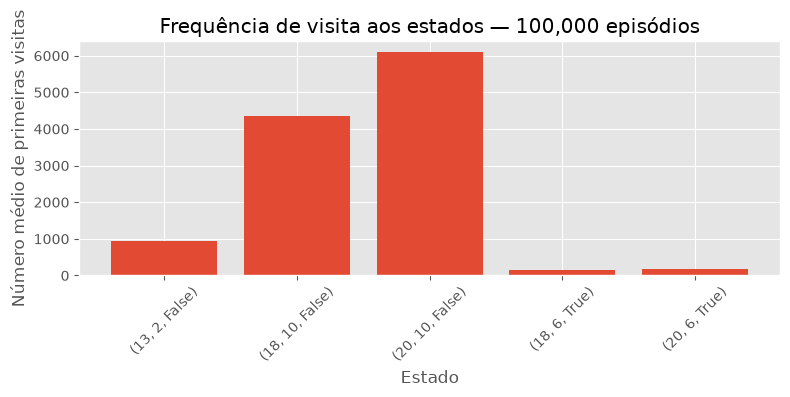

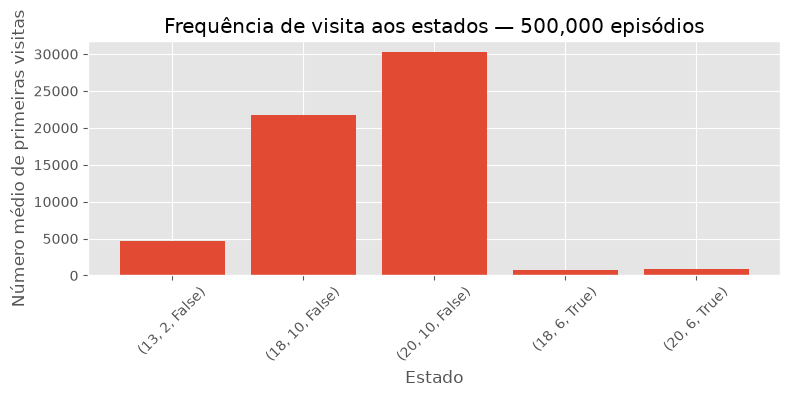

In [14]:
for num_episodes in PREDICTION_EPISODES:

    runs = prediction_results[num_episodes]

    mean_counts = []

    for state in REPRESENTATIVE_STATES:

        counts = [
            run["visit_counts"].get(state, 0)
            for run in runs
        ]

        mean_counts.append(
            np.mean(counts)
        )

    plt.figure(figsize=(8, 4))

    plt.bar(
        [str(state) for state in REPRESENTATIVE_STATES],
        mean_counts
    )

    plt.xlabel("Estado")
    plt.ylabel("Número médio de primeiras visitas")
    plt.title(
        f"Frequência de visita aos estados — {num_episodes:,} episódios"
    )

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 11. Tabela-resumo

A tabela abaixo resume a estabilidade global da estimativa para cada quantidade de episódios.


In [15]:
summary_df = stability_df.copy()

summary_df["Episódios"] = summary_df[
    "Episódios"
].map(lambda x: f"{x:,}")

summary_df


,Episódios,Desvio padrão médio de V,Estados observados
0,"10,000",0.148139,280
1,"100,000",0.043175,280
2,"500,000",0.019333,280


## 12. Pontos para discussão

Os resultados permitem analisar:

1. **Efeito do número de episódios**  
   Se mais amostras reduzem a variabilidade entre execuções.

2. **Estados pouco visitados**  
   Estados raros podem permanecer mais instáveis mesmo com muitos episódios.

3. **Ás utilizável**  
   A presença de ás utilizável altera a dinâmica dos estados.

4. **Limitação do Monte Carlo**  
   A atualização depende do término do episódio, pois o retorno completo precisa ser conhecido.

5. **Ausência de melhoria de política**  
   Nesta etapa, Monte Carlo apenas avalia uma política fixa. A otimização da política será tratada posteriormente em Monte Carlo Control.


## 13. Correspondência com o relatório

| Seção do relatório | Evidência deste notebook |
|---|---|
| Introdução | objetivo e hipótese sobre estabilidade |
| Fundamentação Teórica | Monte Carlo Prediction e First Visit |
| Ambiente | estado, ações, recompensas e término |
| Metodologia | episódios, seeds, política fixa e gamma |
| Resultados | heatmaps de V, estabilidade entre seeds e estados representativos |
| Discussão | efeito da amostragem, estados raros e limitações |
| Conclusões | impacto do número de episódios na estimativa de V |
